In [66]:
import sys
from pathlib import Path

Duong_Dan_Goc = Path(r"D:\HR Analytics")

sys.path.append(
    str(Duong_Dan_Goc / "python" / "src")
)

MODEL_DIR = Duong_Dan_Goc / "python" / "models"
OUTPUT_DIR = Duong_Dan_Goc / "python" / "outputs"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)   
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from db import get_engine

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.base import clone

In [3]:
engine = get_engine()
query="""
select *
from dw.View_ML_NhanVien
order by NgayThang, MaNV
"""
df = pd.read_sql(query, engine)
df["NgayThang"] = pd.to_datetime(df["NgayThang"])
df.head()

,MaNV,NgayThang,Nam,PhongBan,ChucDanh,CapBacCongViec,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,LamThemGio,DiemDanhGiaHieuSuat,DiemHaiLongCongViec,DiemHaiLongMoiTruong,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,DuocThangChucNamTruoc,CoNghiViec
0,5,2018-01-01,2018,Information Technology,IT Support,2,41,15,5,194,False,3,2,3,16936000,7,7,False,0
1,6,2018-01-01,2018,Sales,Sales Supervisor,1,29,16,3,206,False,4,4,3,11779000,7,7,False,0
2,7,2018-01-01,2018,Operations,Operations Manager,2,28,36,1,177,False,2,2,3,15588000,4,4,False,1
3,8,2018-01-01,2018,Human Resources,C&B Specialist,3,35,3,4,240,True,3,1,4,33357000,6,6,False,0
4,10,2018-01-01,2018,Human Resources,C&B Specialist,2,38,35,3,166,False,4,2,2,15353000,4,4,False,0


In [4]:
# Tạo dataset chỉ lấy ngày 01/01
df_du_doan = df[
    (df["NgayThang"].dt.month == 1) &
    (df["NgayThang"].dt.day == 1)
].copy()

# Mục tiêu dự đoán là có nghỉ việc trong 12 tháng hay không
df_du_doan = df_du_doan.rename(
    columns={
        "CoNghiViec": "CoNghiViec12Thang"
    }
)
muc_tieu = "CoNghiViec12Thang"

In [5]:
print("Shape:", df_du_doan.shape)

print("\nSố dòng theo năm:")
print(
    df_du_doan["Nam"]
    .value_counts()
    .sort_index()
)

print("\nmuc_tieu:")
print(
    df_du_doan["CoNghiViec12Thang"]
    .value_counts()
)

print("\nTỷ lệ nghỉ:")
print(
    df_du_doan["CoNghiViec12Thang"]
    .mean()
)

Shape: (33966, 19)

Số dòng theo năm:
Nam
2018    4312
2019    4125
2020    4053
2021    4178
2022    4188
2023    4318
2024    4361
2025    4431
Name: count, dtype: int64

muc_tieu:
CoNghiViec12Thang
0    28703
1     5263
Name: count, dtype: int64

Tỷ lệ nghỉ:
0.1549490667137726


In [6]:
train = df_du_doan[
    df_du_doan["Nam"].between(2018, 2023)
].copy()

valid = df_du_doan[
    df_du_doan["Nam"] == 2024
].copy()

test = df_du_doan[
    df_du_doan["Nam"] == 2025
].copy()

In [7]:
featurea_So= [
    "Tuoi",
    "KhoangCachTuNha",
    "SoLuongDuAn",
    "SoGioTrungBinhThang",
    "DiemDanhGiaHieuSuat",
    "DiemHaiLongCongViec",
    "DiemHaiLongMoiTruong",
    "ThuNhapThang",
    "SoNamTaiCongTy",
    "SoNamTuLanThangChucCuoi",
    "CapBacCongViec"
]
features_Nhi_Phan = [
    "LamThemGio",
    "DuocThangChucNamTruoc"
]
features_danh_muc = [
    "PhongBan",
    "ChucDanh"
]
feature_cot =( featurea_So + features_Nhi_Phan + features_danh_muc)

In [ ]:

knn_tien_xu_ly = ColumnTransformer(
    transformers=[
        (
            "so",
            StandardScaler(),
            featurea_So
        ),

        (
            "nhi_phan",
            "passthrough",
            features_Nhi_Phan
        ),

        (
            "danh_muc",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            features_danh_muc
        )
    ]
)

In [ ]:

knn_pipe = Pipeline(
    steps=[
        (
            "tien_xu_ly",
            knn_tien_xu_ly
        ),

        (
            "mo_hinh",
            KNeighborsClassifier()
        )
    ]
)

In [ ]:
#Tạo x và y
X_train = train[feature_cot].copy()
y_train = train[muc_tieu].copy()

X_valid = valid[feature_cot].copy()
y_valid = valid[muc_tieu].copy()

X_test = test[feature_cot].copy()
y_test = test[muc_tieu].copy()

In [12]:
print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(25174, 15) (25174,)
(4361, 15) (4361,)
(4431, 15) (4431,)


In [21]:
danh_sach_k = [
    3,
    5,
    7,
    9,
    11,
    15,
    21,
    31,
    41,
    51,
     61,
    71,
    81,
    91,
    101,
    121,
    151
]
trong_so = [
    "uniform",
    "distance"
]
cong_thuc = [1, 2]#1 Manhattan, 2 Euclidean

In [ ]:
ket_qua_knn = []

for k in danh_sach_k:
    for trong_so in ["uniform", "distance"]:
        for cong_thuc in [1, 2]:

            mo_hinh = Pipeline(
                steps=[
                    (
                        "tien_xu_ly",
                        knn_tien_xu_ly
                    ),
                    (
                        "mo_hinh",
                        KNeighborsClassifier(
                            n_neighbors=k,
                            weights=trong_so,
                            metric="minkowski",
                            p=cong_thuc
                        )
                    )
                ]
            )

            mo_hinh.fit(
                X_train,
                y_train
            )

            proba = mo_hinh.predict_proba(
                X_valid
            )[:, 1]

            ket_qua_knn.append({
                "K": k,
                "Weights": trong_so,
                "P": cong_thuc,
                "ROC_AUC": roc_auc_score(
                    y_valid,
                    proba
                ),
                "PR_AUC": average_precision_score(
                    y_valid,
                    proba
                )
            })

In [23]:
ket_qua_knn = pd.DataFrame(
    ket_qua_knn
)

ket_qua_knn.sort_values(
    "PR_AUC",
    ascending=False
).head(10)

,K,Weights,P,ROC_AUC,PR_AUC
58,101,distance,1,0.686771,0.296337
62,121,distance,1,0.691101,0.295786
54,91,distance,1,0.687998,0.294254
66,151,distance,1,0.693521,0.293224
50,81,distance,1,0.686313,0.292928
56,101,uniform,1,0.686185,0.290626
60,121,uniform,1,0.691115,0.290547
46,71,distance,1,0.681316,0.289403
52,91,uniform,1,0.688121,0.288580
64,151,uniform,1,0.693219,0.287863


In [ ]:
best_k = 101
best_trong_so= "distance"
best_cong_thuc = 1 #Manhattan

best_knn = Pipeline(
    steps=[
        (
            "tien_xu_ly",
            clone(knn_tien_xu_ly)
        ),
        (
            "mo_hinh",
            KNeighborsClassifier(
                n_neighbors=best_k,
                weights=best_trong_so,
                metric="minkowski",
                p=best_cong_thuc
            )
        )
    ]
)

best_knn.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tien_xu_ly', ...), ('mo_hinh', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Tuoi','KhoangCachTuNha','SoLuongDuAn',...,'DuocThangChucNamTruoc', 'PhongBan','ChucDanh']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('so', ...), ('nhi_phan', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [ ]:
xac_suat_du_doan = best_knn.predict_proba(
    X_valid
)[:, 1]

In [44]:

from sklearn.metrics import (
    precision_recall_curve
)

ds_precision, ds_recall, ds_threshold = (
    precision_recall_curve(
        y_valid,
        xac_suat_du_doan
    )
)

f1_ds_diem = (
    2
    * ds_precision[:-1]
    * ds_recall[:-1]
    /
    (
        ds_precision[:-1]
        + ds_recall[:-1]
        + 1e-9
    )
)

best_idx = np.argmax(f1_ds_diem)

best_threshold = ds_threshold[best_idx]

print(
    "Ngưỡng tốt nhất:",
    round(best_threshold, 4)
)

print(
    "Precision:",
    round(
        ds_precision[best_idx],
        4
    )
)

print(
    "Recall:",
    round(
        ds_recall[best_idx],
        4
    )
)

print(
    "F1:",
    round(
        f1_ds_diem[best_idx],
        4
    )
)

Ngưỡng tốt nhất: 0.1573
Precision: 0.2615
Recall: 0.5498
F1: 0.3544


In [45]:
nhan_du_doan = (
    xac_suat_du_doan >= best_threshold
).astype(int)

In [ ]:
ket_qua_valid = pd.DataFrame(
    {
        "Chi So": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "PR_AUC"
        ],
        "Gia Tri": [
            accuracy_score(
                y_valid,
                nhan_du_doan
            ),
            precision_score(
                y_valid,
                nhan_du_doan
            ),
            recall_score(
                y_valid,
                nhan_du_doan
            ),
            f1_score(
                y_valid,
                nhan_du_doan
            ),
            roc_auc_score(
                y_valid,
                xac_suat_du_doan
            ),
            average_precision_score(
                y_valid,
                xac_suat_du_doan
            )
        ]
    }
)

ket_qua_valid.round(4)

,Chi So,Gia Tri
0,Accuracy,0.7001
1,Precision,0.2615
2,Recall,0.5498
3,F1,0.3544
4,ROC_AUC,0.6868
5,PR_AUC,0.2963


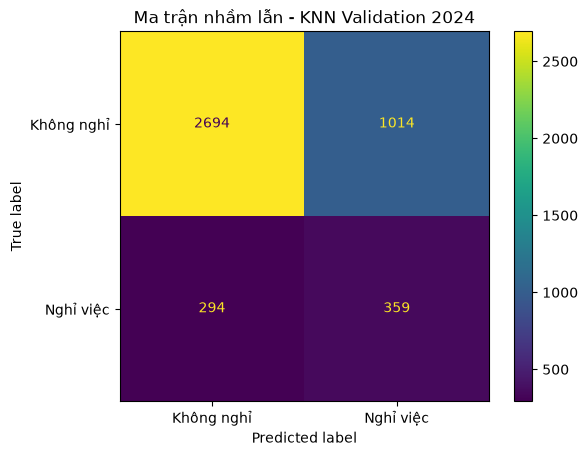

              precision    recall  f1-score   support

  Không nghỉ     0.9016    0.7265    0.8047      3708
   Nghỉ việc     0.2615    0.5498    0.3544       653

    accuracy                         0.7001      4361
   macro avg     0.5815    0.6382    0.5795      4361
weighted avg     0.8058    0.7001    0.7372      4361



In [49]:

ma_tran_nham_lan = confusion_matrix(y_valid, nhan_du_doan)

hien_thi = ConfusionMatrixDisplay(
    confusion_matrix=ma_tran_nham_lan,
    display_labels=["Không nghỉ", "Nghỉ việc"]
)
hien_thi.plot()
plt.title("Ma trận nhầm lẫn - KNN Validation 2024")
plt.show()

print(
    classification_report(
        y_valid,
        nhan_du_doan,
        target_names=["Không nghỉ", "Nghỉ việc"],
        digits=4
    )
)

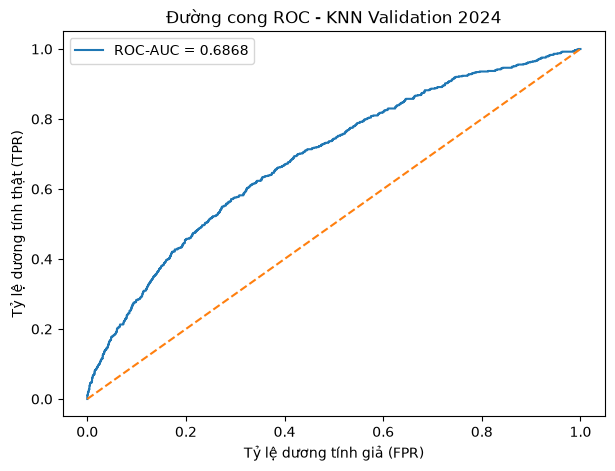

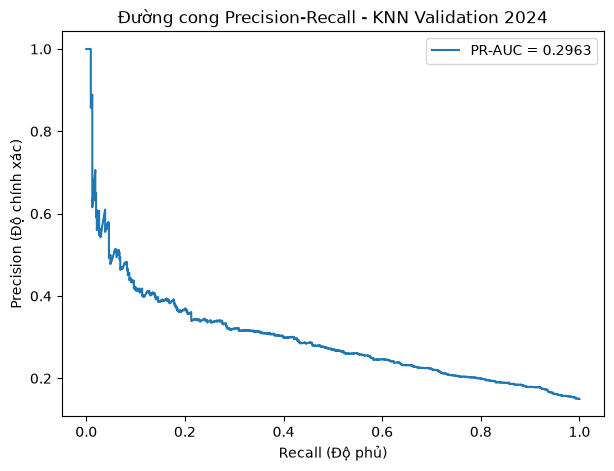

In [ ]:


# Biểu đồ ROC
ty_le_duong_gia, ty_le_duong_that, _ = roc_curve(y_valid, xac_suat_du_doan)

plt.figure(figsize=(7, 5))
plt.plot(
    ty_le_duong_gia, 
    ty_le_duong_that, 
    label=f"ROC-AUC = {roc_auc_score(y_valid, xac_suat_du_doan):.4f}"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Tỷ lệ dương tính giả (FPR)")
plt.ylabel("Tỷ lệ dương tính thật (TPR)")
plt.title("Đường cong ROC - KNN Validation 2024")
plt.legend()
plt.show()

# Biểu đồ Precision-Recall
plt.figure(figsize=(7, 5))
plt.plot(
    ds_recall, 
    ds_precision, 
    label=f"PR-AUC = {average_precision_score(y_valid, xac_suat_du_doan):.4f}"
)
plt.xlabel("Recall (Độ phủ)")
plt.ylabel("Precision (Độ chính xác)")
plt.title("Đường cong Precision-Recall - KNN Validation 2024")
plt.legend()
plt.show()

In [53]:
final_train = df_du_doan[
    df_du_doan["Nam"].between(2018, 2024)
].copy()

final_test = df_du_doan[
    df_du_doan["Nam"] == 2025
].copy()

In [54]:
X_final_train = final_train[
    feature_cot
].copy()

y_final_train = final_train[
    muc_tieu
].copy()

X_final_test = final_test[
    feature_cot
].copy()

y_final_test = final_test[
    muc_tieu
].copy()

In [56]:
final_knn = Pipeline(
    steps=[
        (
            "tien_xu_ly",
            clone(knn_tien_xu_ly)
        ),
        (
            "mo_hinh",
            KNeighborsClassifier(
                n_neighbors=101,
                weights="distance",
                metric="minkowski",
                p=1
            )
        )
    ]
)

final_knn.fit(
    X_final_train,
    y_final_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tien_xu_ly', ...), ('mo_hinh', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Tuoi','KhoangCachTuNha','SoLuongDuAn',...,'DuocThangChucNamTruoc', 'PhongBan','ChucDanh']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('so', ...), ('nhi_phan', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [57]:
xac_suat_kiem_tra = final_knn.predict_proba(
    X_final_test
)[:, 1]

In [58]:
nhan_du_doan_kiem_tra = (
    xac_suat_kiem_tra >= best_threshold
).astype(int)

In [60]:
ket_qua_test = pd.DataFrame({
    "ChiSo": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],

    "GiaTri": [
        accuracy_score(
            y_final_test,
            nhan_du_doan_kiem_tra
        ),

        precision_score(
            y_final_test,
            nhan_du_doan_kiem_tra
        ),

        recall_score(
            y_final_test,
            nhan_du_doan_kiem_tra
        ),

        f1_score(
            y_final_test,
            nhan_du_doan_kiem_tra
        ),

        roc_auc_score(
            y_final_test,
            xac_suat_kiem_tra
        ),

        average_precision_score(
            y_final_test,
            xac_suat_kiem_tra
        )
    ]
})

ket_qua_test.round(4)

,ChiSo,GiaTri
0,Accuracy,0.7064
1,Precision,0.2707
2,Recall,0.5663
3,F1,0.3663
4,ROC_AUC,0.6907
5,PR_AUC,0.3002


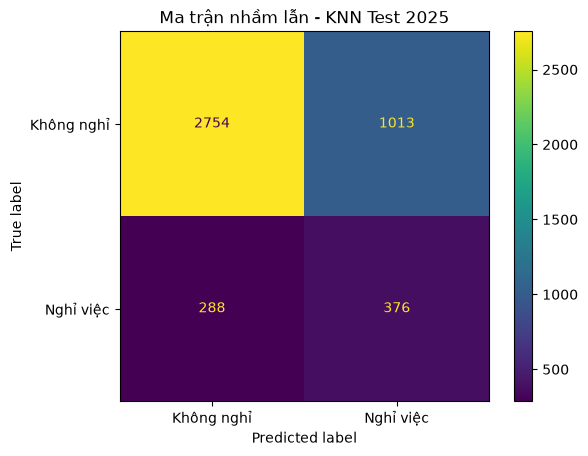

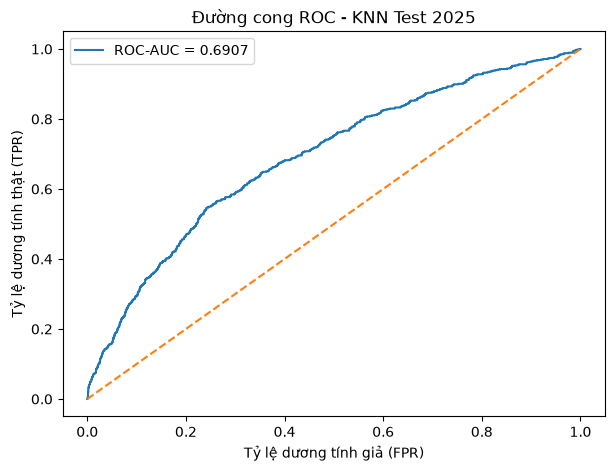

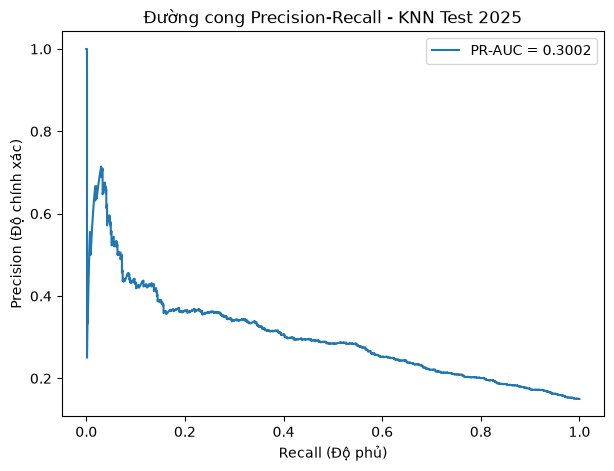

In [61]:
ma_tran_nham_lan_kt = confusion_matrix(y_final_test, nhan_du_doan_kiem_tra)
hien_thi = ConfusionMatrixDisplay(
    confusion_matrix=ma_tran_nham_lan_kt,
    display_labels=["Không nghỉ", "Nghỉ việc"]
)
hien_thi.plot()
plt.title("Ma trận nhầm lẫn - KNN Test 2025")
plt.show()

# 2. Vẽ đường cong ROC
ty_le_duong_gia_kt, ty_le_duong_that_kt, _ = roc_curve(y_final_test, xac_suat_kiem_tra)
plt.figure(figsize=(7, 5))
plt.plot(
    ty_le_duong_gia_kt, 
    ty_le_duong_that_kt, 
    label=f"ROC-AUC = {roc_auc_score(y_final_test, xac_suat_kiem_tra):.4f}"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Tỷ lệ dương tính giả (FPR)")
plt.ylabel("Tỷ lệ dương tính thật (TPR)")
plt.title("Đường cong ROC - KNN Test 2025")
plt.legend()
plt.show()

# 3. Vẽ đường cong Precision-Recall
ds_precision_kt, ds_recall_kt, _ = precision_recall_curve(y_final_test, xac_suat_kiem_tra)
plt.figure(figsize=(7, 5))
plt.plot(
    ds_recall_kt, 
    ds_precision_kt, 
    label=f"PR-AUC = {average_precision_score(y_final_test, xac_suat_kiem_tra):.4f}"
)
plt.xlabel("Recall (Độ phủ)")
plt.ylabel("Precision (Độ chính xác)")
plt.title("Đường cong Precision-Recall - KNN Test 2025")
plt.legend()
plt.show()

In [62]:
ket_qua_du_doan = final_test[
    [
        "MaNV",
        "NgayThang",
        "Nam",
        "PhongBan",
        "ChucDanh"
    ]
].copy()

ket_qua_du_doan[
    "ThucTeNghiViec"
] = y_final_test.values

ket_qua_du_doan[
    "XacSuatNghiViec"
] = xac_suat_kiem_tra

ket_qua_du_doan[
    "DuDoanNghiViec"
] = nhan_du_doan_kiem_tra

In [64]:
ket_qua_du_doan.head(10)

,MaNV,NgayThang,Nam,PhongBan,ChucDanh,ThucTeNghiViec,XacSuatNghiViec,DuDoanNghiViec
35210,1,2025-01-01,2025,Sales,Sales Representative,0,0.154574,0
35211,3,2025-01-01,2025,Finance,Finance Manager,0,0.186049,1
35212,4,2025-01-01,2025,Human Resources,Recruiter,0,0.137610,0
35213,5,2025-01-01,2025,Information Technology,IT Support,0,0.057107,0
35214,10,2025-01-01,2025,Human Resources,C&B Specialist,1,0.146858,0
35215,13,2025-01-01,2025,Sales,Sales Executive,1,0.204404,1
35216,21,2025-01-01,2025,Human Resources,Recruiter,0,0.185729,1
35217,24,2025-01-01,2025,Sales,Sales Representative,1,0.169232,1
35218,28,2025-01-01,2025,Human Resources,C&B Specialist,1,0.122093,0
35219,29,2025-01-01,2025,Human Resources,Recruiter,1,0.150304,0


In [67]:
import joblib

joblib.dump(
    final_knn,
    MODEL_DIR / "knn_model.pkl"
)

['D:\\HR Analytics\\python\\models\\knn_model.pkl']